In [809]:
import os
import json
import ast
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

In [810]:
souradnice = []
dirs = ["downloads/segments/2024-12-27"]
for d in dirs:
    for f in os.listdir(d):
        with open(os.path.join(d, f), "r", encoding="utf-8") as file:
            segment = json.loads(file.read())
            slovnik = {}
            slovnik['jmeno'] = segment['name']
            slovnik['typ'] = segment['activity_type']
            slovnik['souradnice_zacatek'] = segment['start_latlng']
            slovnik['souradnice_konec'] = segment['end_latlng']
            slovnik['mesto'] = segment['city']
            slovnik['pokusy'] = segment['effort_count']
            slovnik['lidi'] = segment['athlete_count']
            slovnik['hvezdy'] = segment['star_count']
            slovnik['delka'] = segment['distance']
            slovnik['nastoupano'] = segment['total_elevation_gain']
            slovnik['zeme'] = segment['country']
            souradnice.append(slovnik)

In [811]:
df = pd.DataFrame(souradnice)
df = df.drop_duplicates(subset='jmeno', keep="last")

In [812]:
zahranici = ['Stelvio - Bormio Turn Downhill','Viveros-Paseo alameda',"Alpe d'Huez",'Richmond ITT1','Box Hill 2.2k','Overtake the Boris Bikes','Passo Stelvio','Col du Tourmalet (par Luz-St-Sauveur)','Viveros-Paseo alameda','Mont Ventoux (par Bedoin)','Sa Calobra - Coll dels Reis','Hilo to Mauna Kea','Sa Calobra - Coll dels Reis','2012 Pikes Peak Hill Climb']

In [813]:
df = df[~df['jmeno'].isin(zahranici)]

In [814]:
len(df)

238

In [815]:
df.sort_values(by='lidi').tail(20)

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme
279,Zlaťák konec - smrt,Ride,"[50.748914, 15.55169]","[50.750899, 15.54882]",Vítkovice,14460,6618,12,507.3,42.10,Czechia
160,"Szlak czerwony, Schronisko Nad Łomniczką - Dom...",Hike,"[50.748323, 15.74398]","[50.739552, 15.729298]",Karpacz,9123,6630,7,2131.5,344.60,Poland
281,Šlechtovka - finální rovinka,Run,"[50.104927, 14.418818]","[50.105409, 14.415785]",Praha 7,155829,6822,11,225.4,0.00,Czechia
75,"Sedmička, Lipno {",Ride,"[48.628827, 14.18491]","[48.632132, 14.23435]",Přední Výtoň,12542,7001,13,4110.2,19.90,Czechia
139,Lužánky rovinka,Run,"[49.207312, 16.605593]","[49.205015, 16.606303]",Brno-střed,179529,7103,21,268.9,3.80,Czechia
158,Od posledního tunelu do Bílovic,Ride,"[49.240786, 16.669932]","[49.245536, 16.675081]",Bílovice nad Svitavou,124240,7456,14,827.8,6.20,Czechia
402,Maslovice - Kralupy,Ride,"[50.207238, 14.362446]","[50.241198, 14.323419]",Máslovice,24468,7962,14,5287.0,33.80,Czech Republic
387,Lysá hora - 5 km,Ride,"[49.527901, 18.48412]","[49.545566, 18.448595]",Staré Hamry,26022,8508,77,4951.0,485.40,Czech Republic
62,Vítkov up sprint,Run,"[50.088014, 14.449721]","[50.088404, 14.451256]",Prague,86417,8588,15,118.2,6.00,Czechia
273,Srbsko - Hlásná Třebáň,Ride,"[49.934198, 14.136199]","[49.922276, 14.197113]",Srbsko,61353,8943,17,5736.1,13.50,Czechia


In [816]:
df.sort_values(by='lidi')

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme
341,Stadion - 400 m,Run,"[49.083832, 15.434145]","[49.083792, 15.434151]",Dačice,1193,23,0,429.6,2.4,Czechia
153,Giro di Tyrš,Run,"[50.222086, 12.199047]","[50.2221, 12.199125]",Aš,1964,39,2,369.4,5.1,Czechia
269,Harusák Climb,Hike,"[49.576854, 16.050244]","[49.572762, 16.044198]",Nové Město na Moravě,71,62,0,683.6,107.2,Czechia
38,Tatran Třemošná,Run,"[49.815305, 13.386864]","[49.815324, 13.386867]",Třemošná,6324,74,4,421.5,7.4,Czech Republic
375,Lacinův kámen - Velká Skála,Hike,"[49.350858, 16.416027]","[49.354554, 16.418434]",Tišnov,91,78,0,1900.0,181.0,Czechia
...,...,...,...,...,...,...,...,...,...,...,...
397,Sedýlko - Praděd climb,Ride,"[50.083718, 17.222208]","[50.083023, 17.231407]",Loučná Nad Desnou,31969,13169,65,1210.1,69.9,Czech Republic
5,"Opičí Časovka, Podolská vodárna - Dvorce",Ride,"[50.059206, 14.419278]","[50.047279, 14.413948]",Prague,322764,16497,57,1390.1,6.0,Czech Republic
230,Zbraslav - Komořany,Ride,"[49.971126, 14.399245]","[49.991221, 14.403886]",Zbraslav,216758,17038,21,2359.0,5.7,Czechia
44,Karlův most ONLY,Run,"[50.086326, 14.413366]","[50.08689, 14.409484]",Prague,37324,18685,29,289.0,2.8,Czech Republic


In [817]:
df['lat'] = df['souradnice_zacatek'].apply(lambda x: x[0])
df['lon'] = df['souradnice_zacatek'].apply(lambda x: x[1])

In [818]:
admin_country = ox.geocode_to_gdf('Czech Republic')

In [819]:
points_gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
)

In [820]:
run_points = points_gdf[points_gdf['typ'] == 'Run']
ride_points = points_gdf[points_gdf['typ'] == 'Ride']
hike_points = points_gdf[points_gdf['typ'] == 'Hike']

In [821]:
len(run_points)

93

In [822]:
len(ride_points)

97

In [823]:
len(hike_points)

48

## Run Segments

<Axes: >

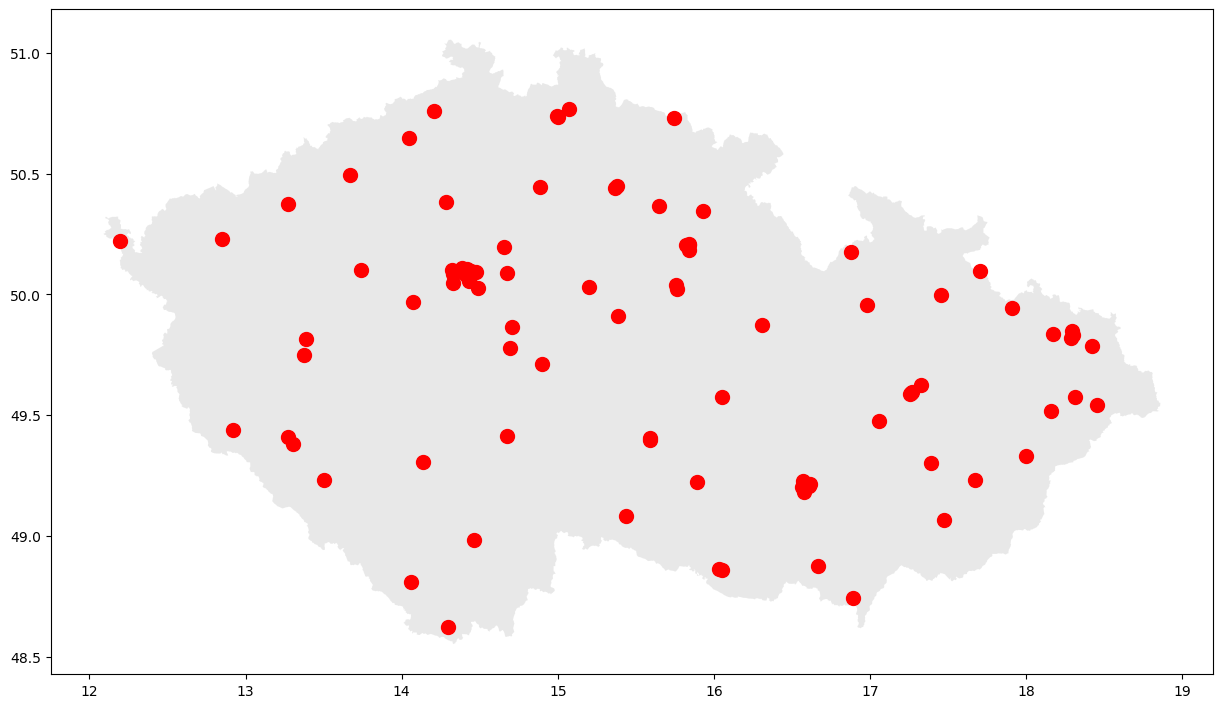

In [825]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
run_points.plot(ax=ax, color='red', marker='o', label='Run', markersize=100)

## Ride Segments

<Axes: >

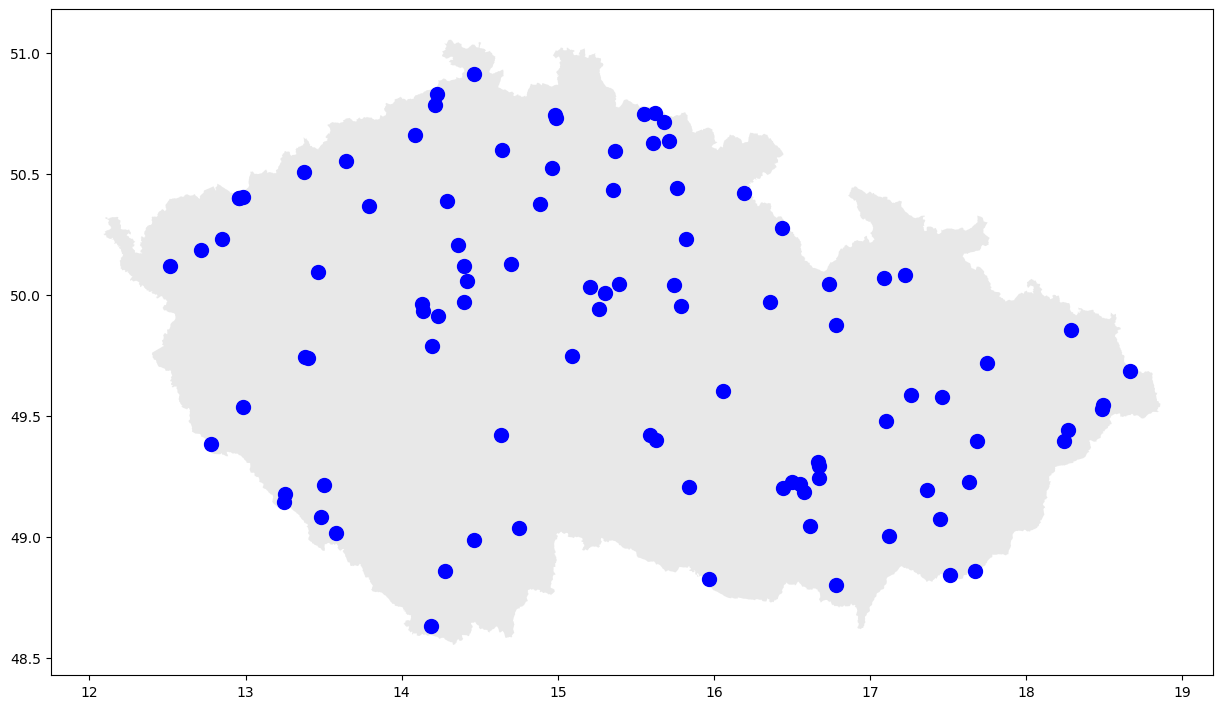

In [827]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
ride_points.plot(ax=ax, color='blue', marker='o', label='Ride', markersize=100)

## Hike segments

<Axes: >

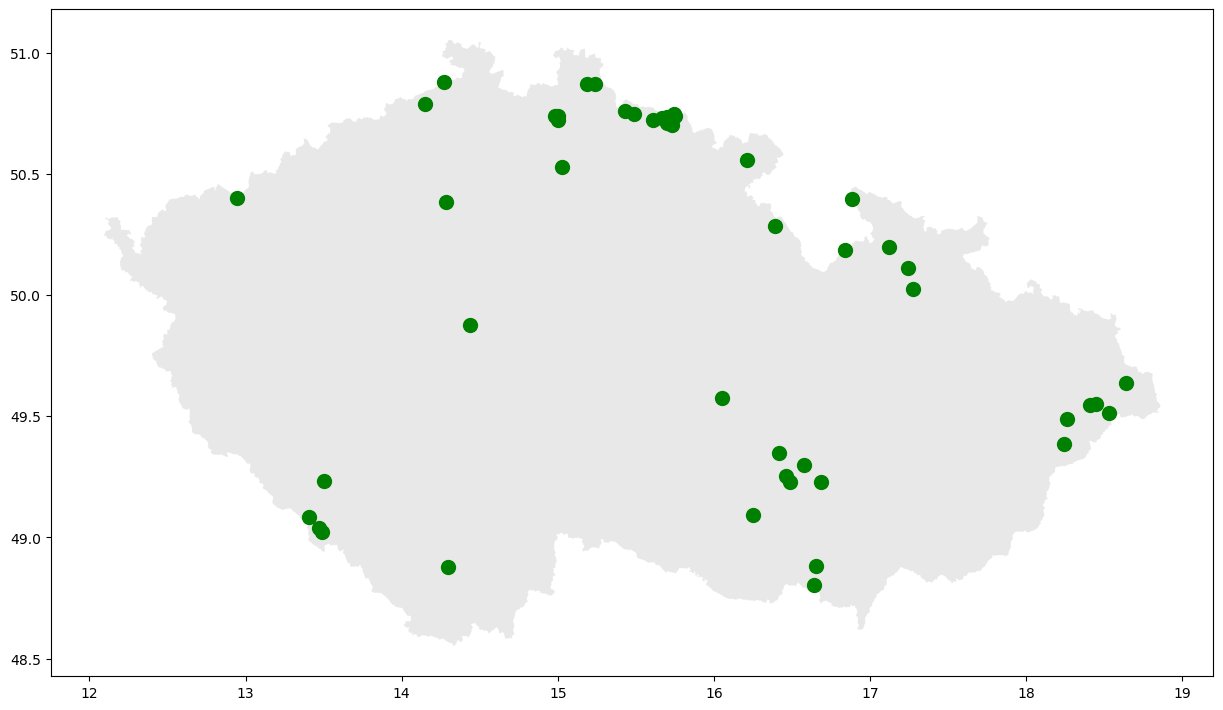

In [829]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
hike_points.plot(ax=ax, color='green', marker='o', label='Hike', markersize=100)

In [830]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth.
    Returns distance in kilometers.
    """
    R = 6371  # Earth's radius in kilometers

    # Convert latitude and longitude to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Differences in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine formula
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return R * c

calculate_distance = lambda row: haversine_distance(
    row['souradnice_zacatek'][1],  # latitude1
    row['souradnice_zacatek'][0],  # longitude1
    row['souradnice_konec'][1],    # latitude2
    row['souradnice_konec'][0]     # longitude2
)

In [831]:
df['vzdalenost_a_b'] = df.apply(calculate_distance, axis=1)

In [832]:
df[df['vzdalenost_a_b'] < 0.025]

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme,lat,lon,vzdalenost_a_b
3,TJ Sokol okruh,Run,"[50.079922, 14.442648]","[50.079996, 14.442586]",Prague,72623,576,25,418.8,5.7,Czech Republic,50.079922,14.442648,0.010537
32,Lužánky - Plochá dráha,Run,"[49.213416, 16.612759]","[49.213428, 16.612745]",Brno,32752,436,9,411.9,0.0,Czech Republic,49.213416,16.612759,0.002015
38,Tatran Třemošná,Run,"[49.815305, 13.386864]","[49.815324, 13.386867]",Třemošná,6324,74,4,421.5,7.4,Czech Republic,49.815305,13.386864,0.002082
41,Prostějov kolo dráha P,Ride,"[49.480251, 17.101977]","[49.480255, 17.101976]",Prostějov,251263,274,3,311.1,0.0,Czech Republic,49.480251,17.101977,0.000439
59,Pražačka 320,Run,"[50.092964, 14.475537]","[50.092971, 14.47553]",Prague,74840,761,13,343.3,0.0,Czechia,50.092964,14.475537,0.001083
77,Tyršák čtyřstofka,Run,"[49.956583, 16.978197]","[49.956597, 16.97823]",Šumperk,46504,350,4,426.5,3.1,Czechia,49.956583,16.978197,0.003960
81,Kolo na stadionu v Třebíči,Run,"[49.224865, 15.892835]","[49.224832, 15.892937]",Třebíč,69313,253,3,475.6,6.2,Czechia,49.224865,15.892835,0.011878
82,Dráha Plzeň okruh P,Ride,"[49.737063, 13.400562]","[49.737035, 13.400547]",Pilsen,54673,141,2,361.9,0.0,Czechia,49.737063,13.400562,0.003458
85,Velodrom 1kolo,Ride,"[50.366907, 13.788866]","[50.366933, 13.788937]",Louny,9533,151,3,492.1,8.9,Czechia,50.366907,13.788866,0.008379
95,Juliska 400 m,Run,"[50.111369, 14.386906]","[50.111375, 14.386867]",Prague,22140,528,3,410.1,10.8,Czechia,50.111369,14.386906,0.004384


In [833]:
df.sort_values(by='vzdalenost_a_b')

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme,lat,lon,vzdalenost_a_b
41,Prostějov kolo dráha P,Ride,"[49.480251, 17.101977]","[49.480255, 17.101976]",Prostějov,251263,274,3,311.1,0.0000,Czech Republic,49.480251,17.101977,0.000439
246,"400 metrů, 44 120 diváků",Run,"[49.212566, 16.611269]","[49.212565, 16.611276]",Brno-Královo Pole,4461,232,2,427.7,4.1000,Czechia,49.212566,16.611269,0.000786
59,Pražačka 320,Run,"[50.092964, 14.475537]","[50.092971, 14.47553]",Prague,74840,761,13,343.3,0.0000,Czechia,50.092964,14.475537,0.001083
134,Track Domažlice,Run,"[49.437031, 12.919155]","[49.437021, 12.919154]",Domažlice,14708,141,0,397.4,5.6000,Czechia,49.437031,12.919155,0.001089
182,Benedikt - Parkoviště,Run,"[50.493445, 13.670016]","[50.49344, 13.670002]",Most,16521,322,4,1995.5,35.7000,Czechia,50.493445,13.670016,0.001648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,Hoštejn-Zábřeh,Ride,"[49.874804, 16.782053]","[49.873756, 16.862426]",None,5892,827,16,7688.6,0.0000,None,49.874804,16.782053,8.937766
355,Židlochovice -> Olympia,Ride,"[49.045781, 16.618217]","[49.13192, 16.633587]",Židlochovice,15857,2325,2,12812.5,20.4000,Czechia,49.045781,16.618217,9.335559
345,Podél dálnice,Ride,"[50.37455, 14.885482]","[50.285802, 14.82927]",Nepřevázka,6229,1409,2,11403.1,44.9728,Czechia,50.374550,14.885482,11.403933
162,Decin - Bad Schandau Abzweig Radwg,Ride,"[50.785068, 14.210443]","[50.911265, 14.171822]",Děčín,15019,6575,14,18518.5,28.0000,Czechia,50.785068,14.210443,14.265965


In [834]:
df[df['typ'] == 'Run'].sort_values(by='vzdalenost_a_b').tail(50)

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme,lat,lon,vzdalenost_a_b
243,Bludička-Opavice,Run,"[49.943187, 17.906602]","[49.939723, 17.911018]",Opava,4900,495,4,578.40,2.40000,Czechia,49.943187,17.906602,0.612741
267,podél Podměstského rybníku,Run,"[49.910406, 15.388152]","[49.905447, 15.391093]",Čáslav,414,132,0,612.50,0.00000,Czechia,49.910406,15.388152,0.624171
297,Rybnik,Run,"[49.30268, 17.392661]","[49.30429, 17.387184]",Kroměříž,1164,255,1,439.10,0.00000,Czechia,49.302680,17.392661,0.632523
261,Šup do parku,Run,"[49.751055, 13.376489]","[49.751577, 13.370791]",Plzeň 1,3937,1047,1,424.90,0.00000,Czechia,49.751055,13.376489,0.636100
318,Kolem stadionu,Run,"[50.207332, 15.842304]","[50.208597, 15.847994]",Hradec Kralove,9667,510,2,449.90,0.00000,Czechia,50.207332,15.842304,0.647008
24,Park 1,Run,"[49.849785, 18.292662]","[49.843515, 18.291888]",Ostrava,13571,2293,10,718.90,0.00000,Czech Republic,49.849785,18.292662,0.667533
253,Z Doubravky k Josefu,Run,"[50.36827, 15.647853]","[50.374782, 15.648103]",Hořice,1310,172,2,796.50,44.20000,Czechia,50.368270,15.647853,0.697818
166,U Jordánu do kopce,Run,"[49.415383, 14.672149]","[49.421943, 14.669218]",Tábor,3562,590,2,984.60,20.30000,Czechia,49.415383,14.672149,0.777284
259,Most - Most -> Břeclav,Run,"[48.742444, 16.89276]","[48.74872, 16.889101]",Břeclav,1230,250,0,807.10,0.00000,Czechia,48.742444,16.892760,0.781941
107,Pisek podel reky I,Run,"[49.306771, 14.138343]","[49.309546, 14.144918]",None,3722,255,6,708.40,7.60000,None,49.306771,14.138343,0.789966


In [835]:
df[df['typ'] == 'Run'].sort_values(by='hvezdy').head(50)

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme,lat,lon,vzdalenost_a_b
180,#ULhalf - Strekovske Nabrezi,Run,"[50.648205, 14.046536]","[50.660068, 14.045844]",Ústí nad Labem-Střekov,6923,1335,0,1435.9,9.80000,Czechia,50.648205,14.046536,1.281976
202,Ku řopíku,Run,"[50.761386, 14.207827]","[50.767416, 14.213276]",Děčín,7706,823,0,794.7,4.40000,Czechia,50.761386,14.207827,0.888595
259,Most - Most -> Břeclav,Run,"[48.742444, 16.89276]","[48.74872, 16.889101]",Břeclav,1230,250,0,807.1,0.00000,Czechia,48.742444,16.892760,0.781941
267,podél Podměstského rybníku,Run,"[49.910406, 15.388152]","[49.905447, 15.391093]",Čáslav,414,132,0,612.5,0.00000,Czechia,49.910406,15.388152,0.624171
84,Kraličák Skyrace - 2. kopec,Run,"[50.175691, 16.879876]","[50.187259, 16.872912]",Staré Město,359,250,0,1571.0,201.80000,Czechia,50.175691,16.879876,1.454223
290,BL Boletice - rovinka na hřebeni,Run,"[48.809638, 14.057585]","[48.801123, 14.057767]",Horní Planá,813,585,0,982.8,2.90000,Czechia,48.809638,14.057585,0.918692
134,Track Domažlice,Run,"[49.437031, 12.919155]","[49.437021, 12.919154]",Domažlice,14708,141,0,397.4,5.60000,Czechia,49.437031,12.919155,0.001089
314,Hradiště - čtyřstovka,Run,"[49.065198, 17.472528]","[49.065226, 17.472453]",Uherské Hradiště,3775,174,0,437.7,0.00000,Czechia,49.065198,17.472528,0.008853
327,Hlavní třídou nahoru,Run,"[49.785712, 18.42023]","[49.78048, 18.430134]",Havířov,1228,457,0,928.7,9.81750,Czechia,49.785712,18.420230,1.231849
341,Stadion - 400 m,Run,"[49.083832, 15.434145]","[49.083792, 15.434151]",Dačice,1193,23,0,429.6,2.40000,Czechia,49.083832,15.434145,0.004339


In [836]:
df.sort_values(by='nastoupano',ascending=False).head(10)

,jmeno,typ,souradnice_zacatek,souradnice_konec,mesto,pokusy,lidi,hvezdy,delka,nastoupano,zeme,lat,lon,vzdalenost_a_b
124,Dlouhe Strane od Loucnej,Ride,"[50.069963, 17.091625]","[50.077466, 17.163214]",Loučná nad Desnou,308,214,7,12619.0,891.800,Czechia,50.069963,17.091625,8.000162
408,Pec - Sněžka (přes Obřák),Hike,"[50.704666, 15.733601]","[50.735868, 15.739865]",Pec pod Sněžkou,3491,1330,4,6374.3,870.300,Czech Republic,50.704666,15.733601,3.411326
51,Pod Vilemínkou - Kralický Sněžník (žlutá),Hike,"[50.185342, 16.841476]","[50.207429, 16.847453]",None,823,571,2,4939.8,595.000,Poland,50.185342,16.841476,2.442740
178,Bečva - Pustevny Uphill,Ride,"[49.440017, 18.265343]","[49.488671, 18.264584]",Prostřední Bečva,6990,2651,99,9570.7,525.400,Czechia,49.440017,18.265343,5.138197
387,Lysá hora - 5 km,Ride,"[49.527901, 18.48412]","[49.545566, 18.448595]",Staré Hamry,26022,8508,77,4951.0,485.400,Czech Republic,49.527901,18.484120,4.367527
185,Dom Śląski Up Hill,Hike,"[50.722256, 15.727193]","[50.738494, 15.729251]",Pec pod Sněžkou,6712,4461,1,2549.5,435.700,Czechia,50.722256,15.727193,1.752980
340,Videlské sedlo-Švýcárna,Hike,"[50.114187, 17.243712]","[50.101476, 17.214157]",Vrbno pod Pradědem,673,252,0,2784.8,421.716,Czechia,50.114187,17.243712,3.552836
187,Javorový od stanice lanovky,Hike,"[49.637066, 18.635969]","[49.628574, 18.627373]",Třinec,6834,1586,18,1265.3,393.200,Czechia,49.637066,18.635969,1.309292
219,Ořešník,Hike,"[50.873311, 15.18525]","[50.859877, 15.190486]",Hejnice,1105,758,2,2324.7,375.700,Czechia,50.873311,15.185250,1.554747
215,Kleť,Hike,"[48.877317, 14.299208]","[48.865463, 14.283662]",Holubov,2622,560,9,1899.1,362.100,Czechia,48.877317,14.299208,2.149351
